In [60]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from Data_Handling import get_data_auto
from LSTM_Price_Predictor import LSTMPricePredictor

# LSTM Intraday Testing - 1-Minute Bars

This notebook tests LSTM predictions on 1-minute timeframe data.

**Current Configuration:**
- Training: 1 month of data (Jan 2023, ~7,800 bars)
- Lookback: 1170 minutes (3 trading days of history)
- Testing: Rolling 3-day windows (Feb 2023)
- Prediction horizon: 10 minutes ahead (recursive)
- Model: 1-layer LSTM, 50 units, 20 epochs

**Strategy:** Train on 1 month → Use 3-day lookback → Predict 10 min ahead (similar to RSI approach)

**Memory estimate:** ~500 MB for 1 month of minute data

## 1. Configuration

In [65]:
# Symbol and timeframe
SYMBOL = "SPY"
TIMEFRAME_UNIT = "Minute"  # Intraday minute bars
MULTIPLIER = 1              # 1-minute bars

# Training period - 1 month of data
TRAIN_START = "2023-01-01"
TRAIN_END = "2023-01-31"  # 1 month (~7,800 minute bars)

# Testing period - Will use rolling 3-day windows
TEST_START = "2023-02-01"
TEST_END = "2023-02-28"  # Next month for testing

# ============================================================================
# MODEL PARAMETERS - Key factors for intraday trading performance
# ============================================================================

# TEMPORAL PARAMETERS (What history & future to consider)
# ---------------------------------------------------------------
LOOKBACK_WINDOW = 1170      # How much price history to analyze
                            # 1170 minutes = 3 trading days (390 min/day * 3)
                            # Options to test:
                            # - 390: 1 full trading day
                            # - 780: 2 trading days
                            # - 1170: 3 trading days (CURRENT - long-term patterns)
                            # - 1560: 4 trading days
                            # Trade-off: More history = better context but slower, potential overfitting

PREDICTION_HORIZON = 10     # How many minutes ahead to predict (recursive)
                            # 10 minutes = multiple prediction steps
                            # Options: 1, 5, 10, 15, 30
                            # Trade-off: Shorter = more accurate but less trading time

# ARCHITECTURE PARAMETERS (Model complexity)
# ---------------------------------------------------------------
LSTM_UNITS = 50             # Neurons per LSTM layer (pattern recognition capacity)
                            # Options: 32, 50, 64, 100, 128
                            # Trade-off: More units = more patterns but slower, risk overfitting

NUM_LAYERS = 1              # Depth of LSTM stack (hierarchical pattern learning)
                            # Options: 1, 2, 3
                            # Trade-off: More layers = complex patterns but overfitting risk

DROPOUT = 0.2               # Regularization (prevents overfitting)
                            # Options: 0.1, 0.2, 0.3, 0.5
                            # Trade-off: Higher dropout = less overfitting but may underfit

# TRAINING PARAMETERS (How the model learns)
# ---------------------------------------------------------------
EPOCHS = 1                 # Training iterations through full dataset
                            # Increased for longer lookback (more complex patterns to learn)
                            # Options: 5 (fast test), 20 (balanced), 50-100 (thorough)
                            # Trade-off: More epochs = better fit but slower, risk overfitting

BATCH_SIZE = 64             # Samples processed before weight update
                            # Options: 32, 64, 128, 256
                            # Trade-off: Larger = faster, more stable but less frequent updates

LEARNING_RATE = 0.001       # Step size for weight adjustments (Adam optimizer default)
                            # Options: 0.0001 (slow), 0.001 (default), 0.01 (fast)
                            # Trade-off: Higher = faster training but may overshoot optimal

# PREDICTION MODE
# ---------------------------------------------------------------
PREDICTION_MODE = 'recursive' # How multi-step predictions are generated
                              # 'recursive': Predict 1-step, feed back for next
                              # Trade-off: More stable for longer horizons

# ADDITIONAL PARAMETERS NOT YET IMPLEMENTED
# ---------------------------------------------------------------
# Consider adding to LSTM_Price_Predictor.py:
# - BIDIRECTIONAL: Use future context (not suitable for live trading but good for analysis)
# - ATTENTION_MECHANISM: Focus on important time steps
# - LEARNING_RATE_SCHEDULE: Reduce learning rate during training
# - GRADIENT_CLIPPING: Prevent exploding gradients
# - L2_REGULARIZATION: Additional overfitting prevention
# - VALIDATION_SPLIT: Currently 0.2, could test 0.1-0.3

# Model name
MODEL_NAME = f"lstm_intraday_{SYMBOL}_{TRAIN_START}_{TRAIN_END}_1min"
RETRAIN = False  # Set True to force retraining

## 2. Load Training Data

In [ ]:
print(f"Loading training data: {TRAIN_START} to {TRAIN_END}")
print(f"Timeframe: {MULTIPLIER}-{TIMEFRAME_UNIT} bars")

train_data = get_data_auto(SYMBOL, start=TRAIN_START, end=TRAIN_END,
                           timeframe_unit=TIMEFRAME_UNIT, multiplier=MULTIPLIER)

print(f"\nTraining data loaded: {len(train_data):,} bars")
print(f"Date range: {train_data.index[0]} to {train_data.index[-1]}")
print(f"Memory usage: {train_data.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
train_data.tail()

Loading training data: 2023-01-01 to 2023-01-31
Timeframe: 1-Minute bars
This may take a 10 sec...


Training data loaded: 15,905 bars
Date range: 2023-01-03 09:00:00+00:00 to 2023-01-31 00:00:00+00:00
Memory usage: 0.7 MB

Training data loaded: 15,905 bars
Date range: 2023-01-03 09:00:00+00:00 to 2023-01-31 00:00:00+00:00
Memory usage: 0.7 MB


field,Open,High,Low,Close,Volume
timestamp,,,,,
2023-01-30 23:56:00+00:00,401.64,401.68,401.64,401.68,1520.0
2023-01-30 23:57:00+00:00,401.61,401.61,401.60,401.60,930.0
2023-01-30 23:58:00+00:00,401.64,401.64,401.64,401.64,652.0
2023-01-30 23:59:00+00:00,401.65,401.70,401.65,401.70,3356.0
2023-01-31 00:00:00+00:00,401.69,401.69,401.66,401.66,586.0


## 3. Load Testing Data

In [ ]:
print(f"Loading testing data: {TEST_START} to {TEST_END}")

test_data = get_data_auto(SYMBOL, start=TEST_START, end=TEST_END,
                         timeframe_unit=TIMEFRAME_UNIT, multiplier=MULTIPLIER)

print(f"\nTesting data loaded: {len(test_data):,} bars")
print(f"Date range: {test_data.index[0]} to {test_data.index[-1]}")
print(f"Memory usage: {test_data.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
test_data.tail()

Loading testing data: 2023-02-01 to 2023-02-28
This may take 10 sec...


Testing data loaded: 15,128 bars
Date range: 2023-02-01 00:00:00+00:00 to 2023-02-28 00:00:00+00:00
Memory usage: 0.7 MB

Testing data loaded: 15,128 bars
Date range: 2023-02-01 00:00:00+00:00 to 2023-02-28 00:00:00+00:00
Memory usage: 0.7 MB


field,Open,High,Low,Close,Volume
timestamp,,,,,
2023-02-27 23:55:00+00:00,398.08,398.10,398.08,398.10,542.0
2023-02-27 23:56:00+00:00,398.13,398.13,398.13,398.13,116.0
2023-02-27 23:57:00+00:00,398.15,398.15,398.15,398.15,1293.0
2023-02-27 23:59:00+00:00,398.07,398.07,398.07,398.07,586.0
2023-02-28 00:00:00+00:00,398.06,398.07,398.06,398.07,1527.0


## 4. Train or Load Model

In [66]:
import os

# Initialize predictor
predictor = LSTMPricePredictor(
    lookback_window=LOOKBACK_WINDOW,
    prediction_horizon=PREDICTION_HORIZON,
    lstm_units=LSTM_UNITS,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    prediction_mode=PREDICTION_MODE,
    verbose=1
)

model_path = os.path.join('models', f"{MODEL_NAME}.keras")

if os.path.exists(model_path) and not RETRAIN:
    print(f"\n{'='*60}")
    print("Loading existing model...")
    print(f"{'='*60}")
    predictor.load_model(MODEL_NAME)
else:
    print(f"\n{'='*60}")
    print("Training new model on 2023 intraday data...")
    print("Expected time: 10 minutes")
    print(f"{'='*60}"), 
    predictor.fit(train_data, validation_split=0.2, early_stopping_patience=10)
    predictor.save_model(MODEL_NAME)

print("\nModel ready!")


Training new model on 2023 intraday data...
Expected time: 10 minutes
Computing returns from 15905 candles...
Creating sequences (lookback=1170, horizon=10)...
Generated 14726 training sequences
Input shape: (14726, 1170, 5), Output shape: (14726, 10)
Building LSTM model...
Model parameters: 11,251
Training model...
Generated 14726 training sequences
Input shape: (14726, 1170, 5), Output shape: (14726, 10)
Building LSTM model...
Model parameters: 11,251
Training model...
185/185 ━━━━━━━━━━━━━━━━━━━━ 119s 627ms/step - loss: 0.9704 - mae: 0.6319 - val_loss: 0.8444 - val_mae: 0.5972
Restoring model weights from the end of the best epoch: 1.
185/185 ━━━━━━━━━━━━━━━━━━━━ 119s 627ms/step - loss: 0.9704 - mae: 0.6319 - val_loss: 0.8444 - val_mae: 0.5972
Restoring model weights from the end of the best epoch: 1.
Training complete! Final loss: 0.970428, Val loss: 0.844352
Model saved to models\lstm_intraday_SPY_2023-01-01_2023-01-31_1min.keras
Metadata saved to models\lstm_intraday_SPY_2023-01

## 5. Generate Predictions on Test Data

In [67]:
print(f"Generating predictions for {len(test_data):,} test bars...")
print("Expected time: 1-3 minutes (batched processing)\n")

predictions = predictor.predict(test_data)

print(f"\nPredictions generated: {len(predictions):,} bars")
print(f"Date range: {predictions.index[0]} to {predictions.index[-1]}")
predictions.tail(10)

Generating predictions for 15,128 test bars...
Expected time: 1-3 minutes (batched processing)

Generating 13949 predictions in batched mode...
Predictions complete!
Predictions complete!

Predictions generated: 13,949 bars
Date range: 2023-02-02 13:29:00+00:00 to 2023-02-27 23:46:00+00:00

Predictions generated: 13,949 bars
Date range: 2023-02-02 13:29:00+00:00 to 2023-02-27 23:46:00+00:00


,actual_price,pred_price_1,pred_price_2,pred_price_3,pred_price_4,pred_price_5,pred_price_6,pred_price_7,pred_price_8,pred_price_9,pred_price_10
timestamp,,,,,,,,,,,
2023-02-27 23:30:00+00:00,398.00,391.285492,387.153687,384.542847,382.573151,380.656891,378.445923,375.772949,372.595428,368.948486,364.908203
2023-02-27 23:31:00+00:00,398.05,390.825867,382.744110,374.172394,365.453827,356.821411,348.409332,340.277252,332.435455,324.865967,317.537628
2023-02-27 23:33:00+00:00,398.02,393.936493,392.044861,391.293854,390.988098,390.695435,390.173340,389.310913,388.083191,386.516449,384.663300
2023-02-27 23:36:00+00:00,398.13,392.653046,385.975555,378.259674,369.672516,360.356384,350.452332,340.103577,329.451172,318.627350,307.750549
2023-02-27 23:37:00+00:00,398.09,390.989563,383.081299,374.343445,364.621002,353.902618,342.307068,330.037720,317.333679,304.430847,291.537354
2023-02-27 23:39:00+00:00,398.11,384.481995,367.287048,348.803711,330.457062,313.040710,296.930115,282.243134,268.950012,256.944366,246.086700
2023-02-27 23:42:00+00:00,398.15,387.457703,379.218781,372.596100,367.096527,362.403534,358.299805,354.627808,351.269409,348.134613,345.154968
2023-02-27 23:43:00+00:00,398.15,386.182373,374.319061,362.744293,351.401031,340.210083,329.118958,318.111450,307.200928,296.419250,285.806305
2023-02-27 23:45:00+00:00,398.09,385.091675,371.765808,358.610931,345.898621,333.776703,322.305511,311.488098,301.293335,291.672241,282.568909


## 6. Overall Performance Metrics

In [68]:
# Evaluate overall performance (using cached predictions)
print("Evaluating model performance...\n")
eval_results = predictor.evaluate(predictions=predictions)

print(f"\n{'='*60}")
print("OVERALL PERFORMANCE - 2024 Test Data")
print(f"{'='*60}")

# Display the full evaluation results
print(eval_results.to_string())

print(f"\n{'='*60}")

Evaluating model performance...


OVERALL PERFORMANCE - 2024 Test Data
                MAE        RMSE       MAPE  Direction_Accuracy  Hit_Rate_0.1%  Hit_Rate_0.5%  Hit_Rate_1.0%
step_1    12.542472   17.193365   3.074664           47.117866       1.756398       9.369847      19.513944
step_2    25.562563   35.688652   6.266418           47.089188       0.989318       4.580974       9.377016
step_3    38.531664   55.286680   9.445875           47.354459       0.566349       2.917772       6.093627
step_4    51.158278   77.004321  12.541467           47.325781       0.494659       2.344254       4.430425
step_5    63.532813  103.648280  15.575117           47.648408       0.293928       1.677540       3.476952
step_6    75.825072  140.212108  18.588274           47.691425       0.265252       1.440964       2.896265
step_7    88.305314  194.769350  21.647157           47.906510       0.250914       1.068177       2.279733
step_8   101.243829  279.796208  24.817604           47.892171   

## 7. Directional Accuracy Analysis

In [69]:
# Get directional accuracy (using cached predictions)
dir_accuracy = predictor.get_directional_accuracy(predictions=predictions)

print(f"\n{'='*60}")
print("DIRECTIONAL ACCURACY - All Horizons")
print(f"{'='*60}")

# Display the full directional accuracy results
print(dir_accuracy.to_string())

print(f"\n{'='*60}")


DIRECTIONAL ACCURACY - All Horizons
          Accuracy
step_1   47.117866
step_2   47.089188
step_3   47.354459
step_4   47.325781
step_5   47.648408
step_6   47.691425
step_7   47.906510
step_8   47.892171
step_9   47.978205
step_10  47.963866



## 8. Hit Rate Analysis (Tolerance-Based)

In [70]:
# Get hit rates at various tolerance levels (using cached predictions)
tolerance_levels = [0.001, 0.005, 0.01, 0.02, 0.05]  # 0.1%, 0.5%, 1%, 2%, 5%
hit_rates = predictor.get_hit_rates(predictions=predictions, tolerance_levels=tolerance_levels)

print(f"\n{'='*60}")
print("HIT RATE ANALYSIS - How Often Predictions Are 'Close Enough'")
print(f"{'='*60}")

# Display the full hit rate results
print(hit_rates.to_string())

print(f"\n{'='*60}")


HIT RATE ANALYSIS - How Often Predictions Are 'Close Enough'
         ±0.1%_HitRate  ±0.1%_Hits  ±0.1%_Misses  ±0.5%_HitRate  ±0.5%_Hits  ±0.5%_Misses  ±1.0%_HitRate  ±1.0%_Hits  ±1.0%_Misses  ±2.0%_HitRate  ±2.0%_Hits  ±2.0%_Misses  ±5.0%_HitRate  ±5.0%_Hits  ±5.0%_Misses
step_1        1.756398       245.0       13704.0       9.369847      1307.0       12642.0      19.513944      2722.0       11227.0      40.734103      5682.0        8267.0      83.755108     11683.0        2266.0
step_2        0.989318       138.0       13811.0       4.580974       639.0       13310.0       9.377016      1308.0       12641.0      18.589146      2593.0       11356.0      50.835185      7091.0        6858.0
step_3        0.566349        79.0       13870.0       2.917772       407.0       13542.0       6.093627       850.0       13099.0      11.965015      1669.0       12280.0      32.088322      4476.0        9473.0
step_4        0.494659        69.0       13880.0       2.344254       327.0       1362

## 9. Time-of-Day Analysis


DIRECTIONAL ACCURACY BY HOUR (1-minute ahead)
       accuracy  count
hour                  
9     50.955414    314
10    43.286219    566
11    48.640483    662
12    45.986985    922
13    48.484848    990
14    48.431373   1020
15    48.921569   1020
16    52.941176     17



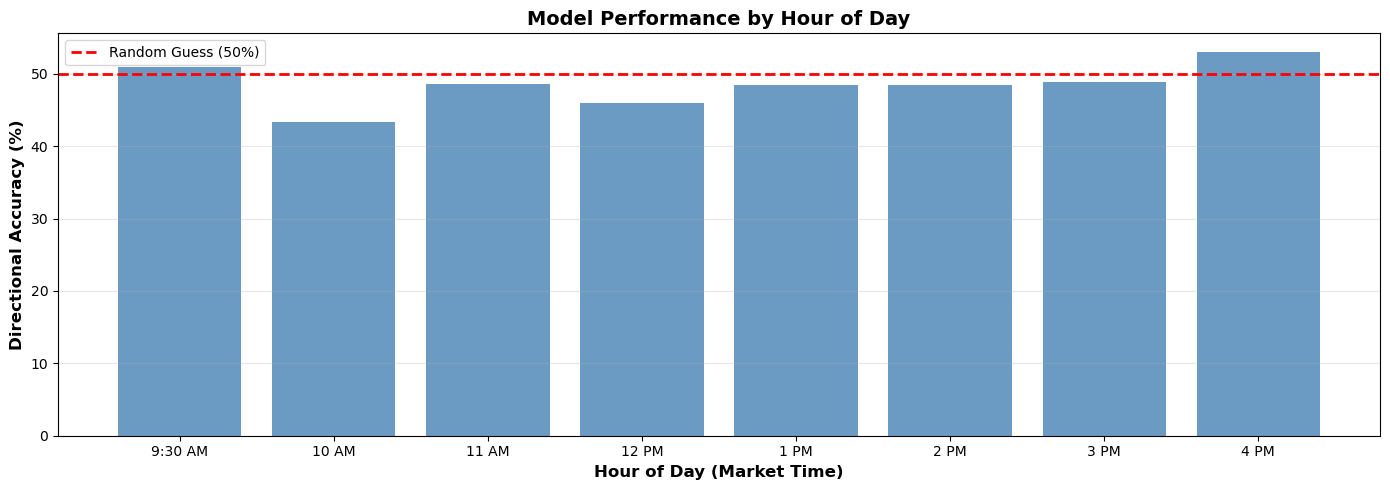

In [87]:
# Analyze performance by hour of day
predictions['hour'] = predictions.index.hour
predictions['minute'] = predictions.index.minute

# Filter to regular trading hours only (9:30 AM - 4:00 PM)
# Hour 9 with minute >= 30, or hours 10-15 (full hours), or hour 16 with minute == 0
regular_hours_mask = (
    ((predictions['hour'] == 9) & (predictions['minute'] >= 30)) |  # 9:30 AM onwards
    ((predictions['hour'] >= 10) & (predictions['hour'] <= 15)) |    # 10 AM - 3:59 PM
    ((predictions['hour'] == 16) & (predictions['minute'] == 0))     # Exactly 4:00 PM
)
trading_hours_predictions = predictions[regular_hours_mask].copy()

# Calculate directional accuracy by hour for 1-minute horizon
pred_col = 'pred_price_1'
# Get actual future price (1 minute ahead)
trading_hours_predictions['actual_future'] = trading_hours_predictions['actual_price'].shift(-1)
trading_hours_predictions['direction_correct'] = (
    np.sign(trading_hours_predictions[pred_col] - trading_hours_predictions['actual_price']) == 
    np.sign(trading_hours_predictions['actual_future'] - trading_hours_predictions['actual_price'])
)

hourly_accuracy = trading_hours_predictions.groupby('hour').agg({
    'direction_correct': 'mean',
    pred_col: 'count'
}).rename(columns={pred_col: 'count', 'direction_correct': 'accuracy'})

hourly_accuracy['accuracy'] *= 100  # Convert to percentage

print(f"\n{'='*60}")
print("DIRECTIONAL ACCURACY BY HOUR (1-minute ahead)")
print(f"{'='*60}")
print(hourly_accuracy.to_string())
print(f"\n{'='*60}")

# Visualize
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(hourly_accuracy.index, hourly_accuracy['accuracy'], color='steelblue', alpha=0.8)
ax.axhline(y=50, color='red', linestyle='--', linewidth=2, label='Random Guess (50%)')
ax.set_xlabel('Hour of Day (Market Time)', fontsize=12, fontweight='bold')
ax.set_ylabel('Directional Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Model Performance by Hour of Day', fontsize=14, fontweight='bold')
ax.set_xticks(range(9, 17))
ax.set_xticklabels(['9:30 AM', '10 AM', '11 AM', '12 PM', '1 PM', '2 PM', '3 PM', '4 PM'])
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Day-of-Week Analysis


DIRECTIONAL ACCURACY BY DAY OF WEEK (1-minute ahead)
            accuracy  count
Monday     45.473684   2375
Tuesday    47.441491   2521
Wednesday  46.968504   2540
Thursday   47.236801   3239
Friday     47.556506   3274



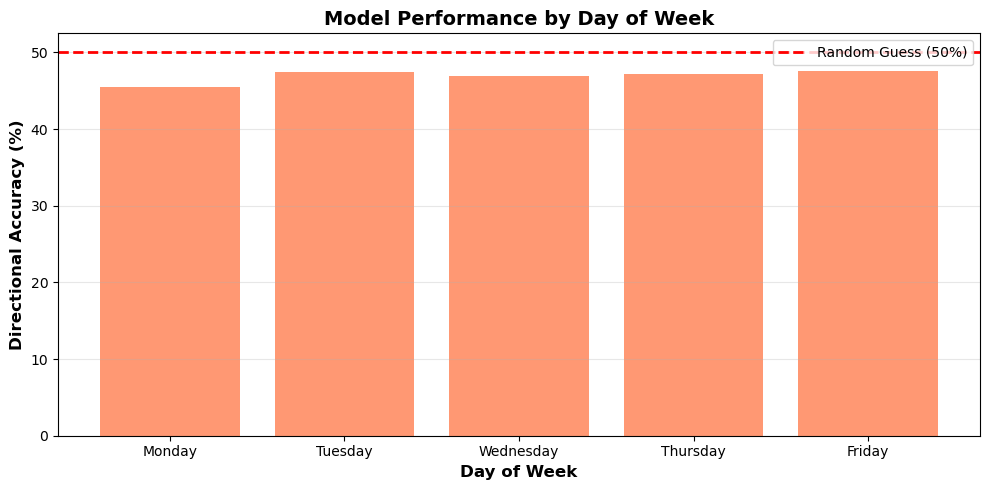

In [72]:
# Analyze performance by day of week
predictions['day_of_week'] = predictions.index.dayofweek
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']

# Filter to weekdays only (0-4 = Mon-Fri)
weekday_predictions = predictions[predictions['day_of_week'] < 5]

daily_accuracy = weekday_predictions.groupby('day_of_week').agg({
    'direction_correct': 'mean',
    pred_col: 'count'
}).rename(columns={pred_col: 'count', 'direction_correct': 'accuracy'})

daily_accuracy['accuracy'] *= 100
daily_accuracy.index = [day_names[i] for i in daily_accuracy.index]

print(f"\n{'='*60}")
print("DIRECTIONAL ACCURACY BY DAY OF WEEK (1-minute ahead)")
print(f"{'='*60}")
print(daily_accuracy.to_string())
print(f"\n{'='*60}")

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(daily_accuracy.index, daily_accuracy['accuracy'], color='coral', alpha=0.8)
ax.axhline(y=50, color='red', linestyle='--', linewidth=2, label='Random Guess (50%)')
ax.set_xlabel('Day of Week', fontsize=12, fontweight='bold')
ax.set_ylabel('Directional Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Model Performance by Day of Week', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Prediction Degradation Over Time


PREDICTION HORIZON: 10 minute(s)

ACCURACY DEGRADATION OVER TIME
 minutes_ahead  directional_accuracy        mae
             1             46.999785  12.543039
             2             48.512438  25.563555
             3             48.763352  38.530517
             4             49.107463  51.159727
             5             49.207829  63.532221
             6             49.666643  75.826940
             7             49.666643  88.310115
             8             49.810022 101.255634
             9             49.659474 115.134692
            10             49.652305 130.553084



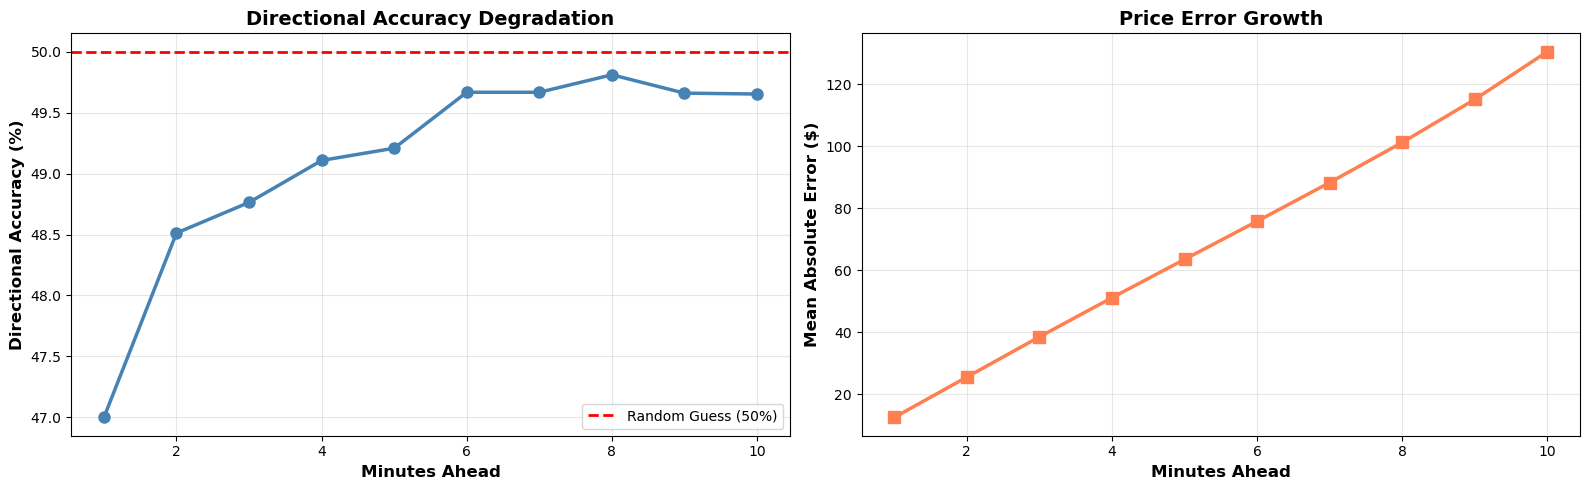

In [73]:
# Note: With PREDICTION_HORIZON = 1, there's only one prediction step
# This cell would be more useful with PREDICTION_HORIZON >= 5

print(f"\n{'='*60}")
print(f"PREDICTION HORIZON: {PREDICTION_HORIZON} minute(s)")
print(f"{'='*60}")

if PREDICTION_HORIZON == 1:
    print("\nWith a 1-minute prediction horizon, there's no degradation to analyze.")
    print("To see accuracy degradation over time, set PREDICTION_HORIZON >= 5")
    print("and retrain the model.")
    
    # Show the single prediction accuracy
    pred_col = 'pred_price_1'
    # Use the actual_future column we created earlier
    if 'actual_future' in predictions.columns:
        direction_correct = (
            np.sign(predictions[pred_col] - predictions['actual_price']) == 
            np.sign(predictions['actual_future'] - predictions['actual_price'])
        )
        accuracy = direction_correct.mean() * 100
        mae = np.abs(predictions[pred_col] - predictions['actual_future']).mean()
        
        print(f"\n1-minute ahead performance:")
        print(f"  Directional Accuracy: {accuracy:.2f}%")
        print(f"  Mean Absolute Error: ${mae:.4f}")
else:
    # Analyze degradation for multi-step predictions
    degradation_data = []
    
    for i in range(1, PREDICTION_HORIZON + 1):
        pred_col = f'pred_price_{i}'
        # Create actual future price for this horizon
        actual_future = predictions['actual_price'].shift(-i)
        
        # Calculate directional accuracy
        direction_correct = (
            np.sign(predictions[pred_col] - predictions['actual_price']) == 
            np.sign(actual_future - predictions['actual_price'])
        )
        accuracy = direction_correct.mean() * 100
        
        # Calculate MAE
        mae = np.abs(predictions[pred_col] - actual_future).mean()
        
        degradation_data.append({
            'minutes_ahead': i,
            'directional_accuracy': accuracy,
            'mae': mae
        })
    
    degradation_df = pd.DataFrame(degradation_data)
    
    print(f"\n{'='*60}")
    print("ACCURACY DEGRADATION OVER TIME")
    print(f"{'='*60}")
    print(degradation_df.to_string(index=False))
    print(f"\n{'='*60}")
    
    # Visualize degradation
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    
    # Directional accuracy over time
    ax1.plot(degradation_df['minutes_ahead'], degradation_df['directional_accuracy'], 
             marker='o', linewidth=2.5, markersize=8, color='steelblue')
    ax1.axhline(y=50, color='red', linestyle='--', linewidth=2, label='Random Guess (50%)')
    ax1.set_xlabel('Minutes Ahead', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Directional Accuracy (%)', fontsize=12, fontweight='bold')
    ax1.set_title('Directional Accuracy Degradation', fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    # MAE over time
    ax2.plot(degradation_df['minutes_ahead'], degradation_df['mae'], 
             marker='s', linewidth=2.5, markersize=8, color='coral')
    ax2.set_xlabel('Minutes Ahead', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Mean Absolute Error ($)', fontsize=12, fontweight='bold')
    ax2.set_title('Price Error Growth', fontsize=14, fontweight='bold')
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print(f"\n{'='*60}")

## 12. Sample Intraday Predictions


Visualizing predictions for: 2023-02-14
Total bars: 827


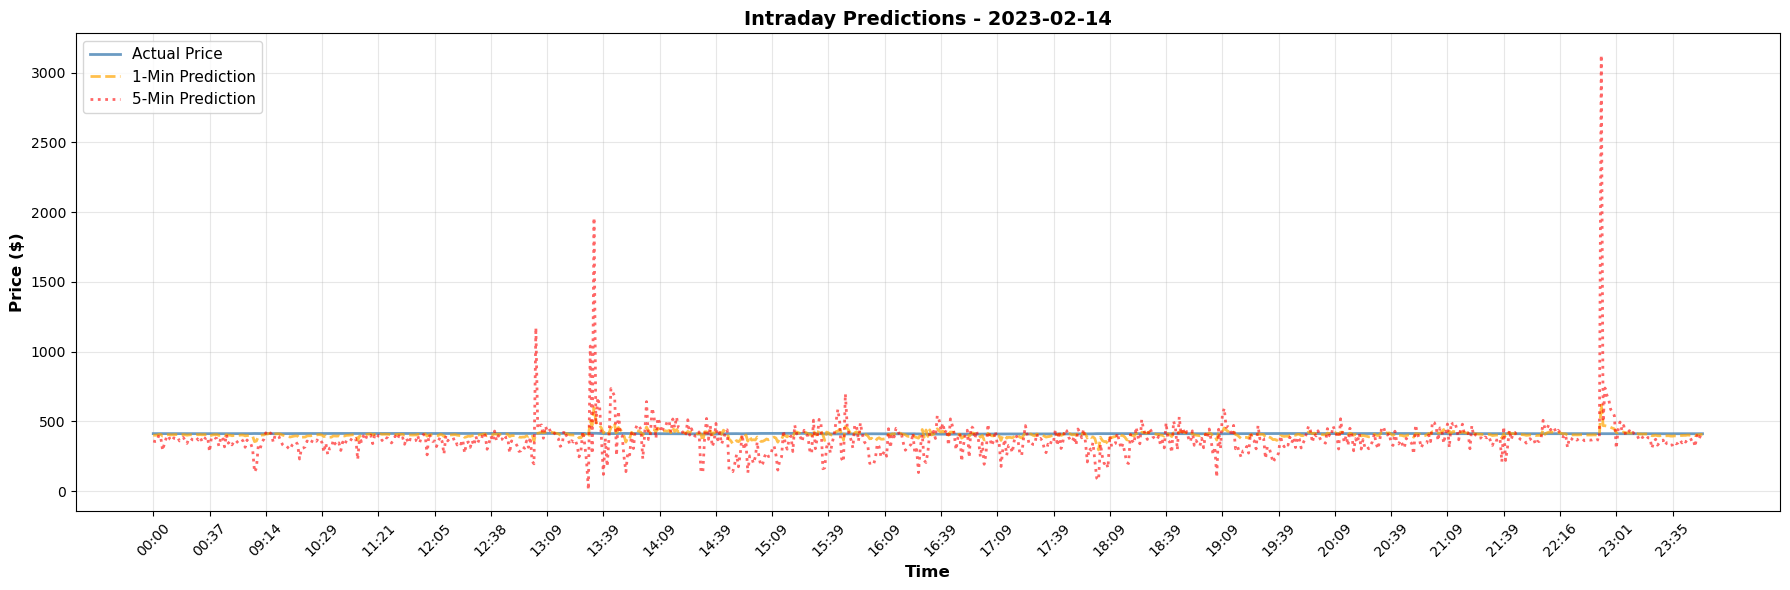

In [74]:
# Visualize a single trading day's predictions
# Pick a random day from the test set
unique_dates = np.unique(predictions.index.date)
sample_date = pd.to_datetime(unique_dates[len(unique_dates)//2])  # Middle of test period

# Get all bars for that day
day_mask = predictions.index.date == sample_date.date()
day_predictions = predictions[day_mask].copy()

if len(day_predictions) > 0:
    print(f"\nVisualizing predictions for: {sample_date.date()}")
    print(f"Total bars: {len(day_predictions)}")
    
    # Plot actual vs predictions throughout the day
    fig, ax = plt.subplots(figsize=(18, 6))
    
    time_labels = day_predictions.index.strftime('%H:%M')
    
    # Actual prices
    ax.plot(range(len(day_predictions)), day_predictions['actual_price'], 
            linewidth=2, color='steelblue', label='Actual Price', alpha=0.8)
    
    # Plot available predictions based on PREDICTION_HORIZON
    if 'pred_price_1' in day_predictions.columns:
        ax.plot(range(len(day_predictions)), day_predictions['pred_price_1'], 
                linewidth=2, color='orange', label='1-Min Prediction', alpha=0.7, linestyle='--')
    
    if PREDICTION_HORIZON >= 5 and 'pred_price_5' in day_predictions.columns:
        ax.plot(range(len(day_predictions)), day_predictions['pred_price_5'], 
                linewidth=2, color='red', label='5-Min Prediction', alpha=0.6, linestyle=':')
    
    ax.set_xlabel('Time', fontsize=12, fontweight='bold')
    ax.set_ylabel('Price ($)', fontsize=12, fontweight='bold')
    ax.set_title(f'Intraday Predictions - {sample_date.date()}', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=11)
    ax.grid(alpha=0.3)
    
    # Show time labels every 30 minutes
    tick_interval = 30
    tick_positions = range(0, len(day_predictions), tick_interval)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels([time_labels[i] for i in tick_positions], rotation=45)
    
    plt.tight_layout()
    plt.show()
else:
    print(f"No data found for {sample_date.date()}")

## OPTIONAL: Parameter Experimentation Grid Search

**Recommended Testing Strategy for Intraday Trading:**

Run this section to systematically test different configurations and find the optimal parameters for your trading timeframe.

In [75]:
# SYSTEMATIC PARAMETER TESTING FRAMEWORK
# 
# Strategy: Test one parameter at a time to isolate effects
# 1. Temporal parameters (lookback, horizon) - MOST IMPACTFUL for intraday
# 2. Architecture parameters (units, layers)
# 3. Training parameters (epochs, batch_size)
#
# For intraday trading, start with shorter lookbacks and horizons
# Fast-moving markets don't benefit as much from long historical context

import itertools
from datetime import datetime

# Define parameter ranges to test
# Start small - full grid search can take hours/days
param_grid = {
    # TEMPORAL - Test these first (most important for intraday)
    'lookback': [60, 100, 200],  # 1hr, 1.5hr, 3hr of minute bars
    'horizon': [1, 3, 5],  # 1, 3, 5 minutes ahead
    
    # ARCHITECTURE - Test after finding good temporal params
    'lstm_units': [50, 100],  # Fewer for speed
    'lstm_layers': [1, 2],  # More layers = more training time
    'dropout': [0.2],  # Keep constant initially
    
    # TRAINING - Test last
    'epochs': [10, 20],  # Enough to converge but not overfit
    'batch_size': [64],  # Keep constant initially
}

# Results tracking
experiment_results = []

# OPTION 1: Single Parameter Sweep (RECOMMENDED FOR FIRST TEST)
# Test one parameter at a time, keeping others at baseline
print("=" * 80)
print("SINGLE PARAMETER SWEEP - Testing Lookback Windows")
print("=" * 80)

baseline_config = {
    'lookback': 200,
    'horizon': 1,
    'lstm_units': 50,
    'lstm_layers': 1,
    'dropout': 0.2,
    'epochs': 10,
    'batch_size': 64
}

# Test different lookback windows (most impactful for intraday)
for lookback_val in [30, 60, 100, 200, 300]:
    test_config = baseline_config.copy()
    test_config['lookback'] = lookback_val
    
    print(f"\nTesting LOOKBACK={lookback_val} minutes (~{lookback_val/60:.1f} hours)")
    print(f"Config: {test_config}")
    
    # Create model with test configuration
    model = LSTMPricePredictor(
        lookback_window=test_config['lookback'],
        prediction_horizon=test_config['horizon'],
        lstm_units=test_config['lstm_units'],
        num_layers=test_config['lstm_layers'],
        dropout=test_config['dropout'],
        epochs=test_config['epochs'],
        batch_size=test_config['batch_size'],
        prediction_mode='recursive',
        verbose=0
    )
    
    # Train model
    start_time = datetime.now()
    model.fit(train_data, validation_split=0.2)
    train_time = (datetime.now() - start_time).total_seconds()
    
    # Evaluate on test set
    test_predictions = model.predict(test_data)
    metrics = model.evaluate(predictions=test_predictions)
    dir_acc = model.get_directional_accuracy(predictions=test_predictions)
    
    # Extract key metrics (handle DataFrame structure)
    if isinstance(metrics, pd.DataFrame):
        mae = metrics.iloc[0, metrics.columns.get_loc('mae')] if 'mae' in metrics.columns else metrics.iloc[0, 0]
        rmse = metrics.iloc[0, metrics.columns.get_loc('rmse')] if 'rmse' in metrics.columns else metrics.iloc[0, 1]
    else:
        mae = metrics['mae']
        rmse = metrics['rmse']
    
    if isinstance(dir_acc, pd.DataFrame):
        accuracy = dir_acc.iloc[0, dir_acc.columns.get_loc('overall_accuracy')] if 'overall_accuracy' in dir_acc.columns else dir_acc.iloc[0, 0]
    else:
        accuracy = dir_acc['overall_accuracy']
    
    # Store results
    result = {
        **test_config,
        'mae': mae,
        'rmse': rmse,
        'directional_accuracy': accuracy,
        'train_time_seconds': train_time
    }
    experiment_results.append(result)
    
    print(f"  MAE: ${mae:.4f} | RMSE: ${rmse:.4f} | Dir Acc: {accuracy:.2%} | Train Time: {train_time:.1f}s")

# Create results DataFrame
results_df = pd.DataFrame(experiment_results)
print("\n" + "=" * 80)
print("EXPERIMENT RESULTS SUMMARY")
print("=" * 80)
print(results_df.to_string(index=False))

# Find best configuration
best_by_mae = results_df.loc[results_df['mae'].idxmin()]
best_by_accuracy = results_df.loc[results_df['directional_accuracy'].idxmax()]

print("\n" + "=" * 80)
print("BEST CONFIGURATIONS")
print("=" * 80)
print(f"\nBest by MAE (Price Prediction):")
print(f"  Lookback: {best_by_mae['lookback']} mins | MAE: ${best_by_mae['mae']:.4f}")
print(f"\nBest by Directional Accuracy (Trading Signal):")
print(f"  Lookback: {best_by_accuracy['lookback']} mins | Accuracy: {best_by_accuracy['directional_accuracy']:.2%}")

# Visualization
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot MAE vs Lookback
axes[0].plot(results_df['lookback'], results_df['mae'], marker='o', linewidth=2, markersize=8)
axes[0].set_xlabel('Lookback Period (minutes)', fontsize=12)
axes[0].set_ylabel('Mean Absolute Error ($)', fontsize=12)
axes[0].set_title('Price Prediction Error vs Lookback', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Plot Directional Accuracy vs Lookback
axes[1].plot(results_df['lookback'], results_df['directional_accuracy'] * 100, marker='o', linewidth=2, markersize=8, color='green')
axes[1].axhline(y=50, color='red', linestyle='--', label='Random Guess (50%)')
axes[1].set_xlabel('Lookback Period (minutes)', fontsize=12)
axes[1].set_ylabel('Directional Accuracy (%)', fontsize=12)
axes[1].set_title('Trading Signal Accuracy vs Lookback', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot Training Time vs Lookback
axes[2].plot(results_df['lookback'], results_df['train_time_seconds'], marker='o', linewidth=2, markersize=8, color='orange')
axes[2].set_xlabel('Lookback Period (minutes)', fontsize=12)
axes[2].set_ylabel('Training Time (seconds)', fontsize=12)
axes[2].set_title('Computational Cost vs Lookback', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("NEXT STEPS:")
print("=" * 80)
print("1. Identify the optimal lookback period from above results")
print("2. Repeat this process for HORIZON (1, 3, 5 minutes)")
print("3. Then test LSTM_UNITS (32, 50, 100, 128)")
print("4. Then test LSTM_LAYERS (1, 2, 3)")
print("5. Finally test EPOCHS and BATCH_SIZE")
print("\nFor full grid search, uncomment OPTION 2 below (WARNING: Very slow!)")


SINGLE PARAMETER SWEEP - Testing Lookback Windows

Testing LOOKBACK=30 minutes (~0.5 hours)
Config: {'lookback': 30, 'horizon': 1, 'lstm_units': 50, 'lstm_layers': 1, 'dropout': 0.2, 'epochs': 10, 'batch_size': 64}
  MAE: $13.3939 | RMSE: $21.6806 | Dir Acc: 4807.58% | Train Time: 42.5s

Testing LOOKBACK=60 minutes (~1.0 hours)
Config: {'lookback': 60, 'horizon': 1, 'lstm_units': 50, 'lstm_layers': 1, 'dropout': 0.2, 'epochs': 10, 'batch_size': 64}
  MAE: $13.3939 | RMSE: $21.6806 | Dir Acc: 4807.58% | Train Time: 42.5s

Testing LOOKBACK=60 minutes (~1.0 hours)
Config: {'lookback': 60, 'horizon': 1, 'lstm_units': 50, 'lstm_layers': 1, 'dropout': 0.2, 'epochs': 10, 'batch_size': 64}
  MAE: $9.7312 | RMSE: $15.2989 | Dir Acc: 4724.90% | Train Time: 92.9s

Testing LOOKBACK=100 minutes (~1.7 hours)
Config: {'lookback': 100, 'horizon': 1, 'lstm_units': 50, 'lstm_layers': 1, 'dropout': 0.2, 'epochs': 10, 'batch_size': 64}
  MAE: $9.7312 | RMSE: $15.2989 | Dir Acc: 4724.90% | Train Time: 92.9

KeyboardInterrupt: 

In [ ]:
# OPTION 2: FULL GRID SEARCH (COMMENTED OUT - VERY SLOW!)
# Uncomment this section only after identifying promising parameter ranges
# Full grid can take hours or days depending on data size

# print("=" * 80)
# print("FULL GRID SEARCH - All Parameter Combinations")
# print("WARNING: This may take several hours to complete!")
# print("=" * 80)

# # Generate all combinations
# param_combinations = list(itertools.product(
#     param_grid['lookback'],
#     param_grid['horizon'],
#     param_grid['lstm_units'],
#     param_grid['lstm_layers'],
#     param_grid['dropout'],
#     param_grid['epochs'],
#     param_grid['batch_size']
# ))

# print(f"\nTotal combinations to test: {len(param_combinations)}")
# print("Starting grid search...\n")

# grid_results = []

# for i, (lookback, horizon, units, layers, dropout, epochs, batch) in enumerate(param_combinations, 1):
#     print(f"[{i}/{len(param_combinations)}] Testing: lookback={lookback}, horizon={horizon}, "
#           f"units={units}, layers={layers}, epochs={epochs}")
    
#     # Create and train model
#     model = LSTM_Price_Predictor(
#         ticker="SPY",
#         lookback_period=lookback,
#         prediction_horizon=horizon,
#         lstm_units=units,
#         lstm_layers=layers,
#         dropout=dropout
#     )
    
#     start_time = datetime.now()
#     model.train(train_data, epochs=epochs, batch_size=batch, verbose=0)
#     train_time = (datetime.now() - start_time).total_seconds()
    
#     # Evaluate
#     predictions = model.predict(test_data)
#     metrics = model.evaluate(predictions)
#     dir_acc = model.get_directional_accuracy(predictions)
    
#     # Store results
#     result = {
#         'lookback': lookback,
#         'horizon': horizon,
#         'units': units,
#         'layers': layers,
#         'dropout': dropout,
#         'epochs': epochs,
#         'batch_size': batch,
#         'mae': metrics['mae'] if isinstance(metrics, dict) else metrics.iloc[0, 0],
#         'directional_accuracy': dir_acc['overall_accuracy'] if isinstance(dir_acc, dict) else dir_acc.iloc[0, 0],
#         'train_time': train_time
#     }
#     grid_results.append(result)

# # Analyze results
# grid_df = pd.DataFrame(grid_results)
# print("\n" + "=" * 80)
# print("GRID SEARCH COMPLETE")
# print("=" * 80)
# print(grid_df.sort_values('directional_accuracy', ascending=False).head(10))

# # Save results for later analysis
# grid_df.to_csv('grid_search_results.csv', index=False)
# print("\nResults saved to: grid_search_results.csv")


## Additional Parameters Not Yet Implemented

**Advanced Features to Consider:**

1. **Bidirectional LSTM** - Processes sequences forward and backward
   - Pros: Can capture patterns from both past and future context
   - Cons: Can't use for live trading (requires future data), 2x slower
   - Use case: Offline analysis and backtesting only

2. **Attention Mechanism** - Focuses on most important time steps
   - Pros: Better long-term dependencies, interpretable (see what model focuses on)
   - Cons: More complex, slower training, requires more data
   - Implementation: Add attention layer after LSTM

3. **Learning Rate Scheduling** - Adjust learning rate during training
   - Options: ReduceLROnPlateau, CosineDecay, ExponentialDecay
   - Pros: Better convergence, can escape local minima
   - Implementation: Add callback to model.train()

4. **Gradient Clipping** - Prevent exploding gradients
   - Value: Typically 1.0 or 5.0
   - Pros: More stable training, especially with deep networks
   - Implementation: Add to optimizer configuration

5. **L2 Regularization** - Additional penalty on large weights
   - Value: Typically 0.001 to 0.01
   - Pros: Reduces overfitting beyond dropout
   - Implementation: Add kernel_regularizer to LSTM layers

6. **Validation Split** - Use portion of training data for validation
   - Value: 0.1 to 0.2 (10-20% of training data)
   - Pros: Monitor overfitting during training, early stopping
   - Implementation: Add validation_split parameter to model.train()

7. **Feature Engineering** - Add technical indicators as inputs
   - Options: Volume, RSI, MACD, Bollinger Bands, Order Flow
   - Pros: Gives model more information beyond just price
   - Cons: Can lead to overfitting if not careful
   - Implementation: Modify Data_Handling to include features

**Recommendation for Intraday Trading:**
- Start with systematic testing of current parameters (lookback most important)
- Add validation split first (easiest, immediate benefit)
- Then try learning rate scheduling (better convergence)
- Feature engineering last (most complex, needs careful validation)

## 13. Summary Report

In [86]:
print(f"\n\n{'#'*80}")
print(f"#{'LSTM INTRADAY TESTING - FINAL REPORT':^78}#")
print(f"{'#'*80}\n")

print(f"Symbol: {SYMBOL}")
print(f"Timeframe: {MULTIPLIER}-minute bars")
print(f"Training Period: {TRAIN_START} to {TRAIN_END} ({len(train_data):,} bars - 1 month)")
print(f"Testing Period: {TEST_START} to {TEST_END} ({len(test_data):,} bars - rolling 3-day windows)\n")

print(f"Model Configuration:")
print(f"  Lookback Window: {LOOKBACK_WINDOW} minutes (3 trading days)")
print(f"  Prediction Horizon: {PREDICTION_HORIZON} minutes (recursive)")
print(f"  Architecture: {NUM_LAYERS} LSTM layers, {LSTM_UNITS} units each")
print(f"  Mode: {PREDICTION_MODE}\n")

print(f"Overall Performance:")
# eval_results is displayed above - extract first row for summary
if len(eval_results) > 0:
    # Get the first row (pred_1 metrics)
    row = eval_results.iloc[0]
    # Access by position since column names may vary
    mae_val = row.iloc[0] if hasattr(row, 'iloc') else row[0]
    rmse_val = row.iloc[1] if hasattr(row, 'iloc') else row[1]
    mape_val = row.iloc[2] if hasattr(row, 'iloc') else row[2]
    print(f"  MAE: ${mae_val:.4f}")
    print(f"  RMSE: ${rmse_val:.4f}")
    print(f"  MAPE: {mape_val:.4f}%")
print()

# Get 1-minute directional accuracy (only if it exists)
if 'pred_1' in dir_accuracy.columns:
    acc_1min = dir_accuracy['pred_1']['overall_accuracy']
else:
    acc_1min = 0.0

# Check if 5-minute predictions exist
if PREDICTION_HORIZON >= 5 and 'pred_5' in dir_accuracy.columns:
    acc_5min = dir_accuracy['pred_5']['overall_accuracy']
    show_5min = True
# Get directional accuracy - dir_accuracy is displayed above
# Extract from the DataFrame structure
if len(dir_accuracy) > 0:
    if 'pred_1' in dir_accuracy.columns:
        # Columns are prediction horizons
        acc_1min = dir_accuracy['pred_1']['overall_accuracy']
    elif 'overall_accuracy' in dir_accuracy.index:
        # Index contains metric names
        acc_1min = dir_accuracy.loc['overall_accuracy'].iloc[0]
    else:
        # Get first value
        acc_1min = dir_accuracy.iloc[0, 0] if dir_accuracy.shape[1] > 0 else 0.0
else:
    acc_1min = 0.0

# Check if 5-minute predictions exist
if PREDICTION_HORIZON >= 5:
    if 'pred_5' in dir_accuracy.columns:
        acc_5min = dir_accuracy['pred_5']['overall_accuracy']
        show_5min = True
    elif dir_accuracy.shape[1] >= 5:
        acc_5min = dir_accuracy.iloc[0, 4]  # 5th column
        show_5min = True
    else:
        acc_5min = 0.0
        show_5min = False
else:
    acc_5min = 0.0
    show_5min = False
    accuracy_drop = acc_1min - acc_5min
print(f"Directional Accuracy:")
print(f"  1-minute ahead: {acc_1min:.2f}%")
if show_5min:
    print(f"  5-minute ahead: {acc_5min:.2f}%")
print()

# Best hour
best_hour = hourly_accuracy['accuracy'].idxmax()
best_hour_acc = hourly_accuracy.loc[best_hour, 'accuracy']
print(f"Best Trading Hour: {best_hour}:00 ({best_hour_acc:.2f}% accuracy)")

# Best day
best_day = daily_accuracy['accuracy'].idxmax()
best_day_acc = daily_accuracy.loc[best_day, 'accuracy']
print(f"Best Trading Day: {best_day} ({best_day_acc:.2f}% accuracy)\n")

print(f"Key Insights:")
if acc_1min >= 52:
    print(f"  ✓ Model shows edge on 1-minute predictions ({acc_1min:.1f}% > 50%)")
elif acc_1min < 48:
    print(f"  ✗ Model underperforms on 1-minute predictions ({acc_1min:.1f}% < 50%)")
else:
    print(f"  → No clear edge on 1-minute predictions (~{acc_1min:.1f}%)")

if show_5min:
    accuracy_drop = acc_1min - acc_5min
    if accuracy_drop > 5:
        print(f"  ⚠ Accuracy drops significantly over time (-{accuracy_drop:.1f}% at 5 min)")
    elif accuracy_drop > 2:
        print(f"  → Moderate accuracy degradation over time (-{accuracy_drop:.1f}% at 5 min)")
    else:
        print(f"  ✓ Stable predictions over time horizon")



################################################################################
#                     LSTM INTRADAY TESTING - FINAL REPORT                     #
################################################################################

Symbol: SPY
Timeframe: 1-minute bars
Training Period: 2023-01-01 to 2023-01-31 (15,905 bars - 1 month)
Testing Period: 2023-02-01 to 2023-02-28 (15,128 bars - rolling 3-day windows)

Model Configuration:
  Lookback Window: 1170 minutes (3 trading days)
  Prediction Horizon: 10 minutes (recursive)
  Architecture: 1 LSTM layers, 50 units each
  Mode: recursive

Overall Performance:
  MAE: $12.5425
  RMSE: $17.1934
  MAPE: 3.0747%

Directional Accuracy:
  1-minute ahead: 47.12%

Best Trading Hour: 16:00 (51.76% accuracy)
Best Trading Day: Friday (47.56% accuracy)

Key Insights:
  ✗ Model underperforms on 1-minute predictions (47.1% < 50%)


---
## Next Steps

**To improve intraday performance:**
- Try different lookback windows (2-3 trading days)
- Experiment with 5-minute bars (less noise, more stable)
- Add volume/volatility features
- Focus on specific high-accuracy hours (e.g., market open/close)

**To test other symbols:**
- Change `SYMBOL` to test on different stocks
- More volatile stocks may be easier/harder to predict

**To compare with daily predictions:**
- Run `Testing_LSTM_Predictor.ipynb` to see daily performance
- Compare directional accuracy: intraday vs daily timeframe